In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path

import os
os.chdir(os.path.expanduser('~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg'))
ROOT = Path.cwd()


In [4]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')
# list all packages and their versions
sc.logging.print_versions()

/var/folders/1r/3rf4xlj152j5n2bfyjq1v58c0000gn/T/ipykernel_10298/3232310332.py:5: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  sc.logging.print_versions()


Package,Version
bio-pyminer-norm,0.2.6
Component,Info
Python,"3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]"
OS,macOS-15.6.1-arm64-arm-64bit
CPU,"12 logical CPU cores, arm"
GPU,No GPU found
Updated,2025-12-11 18:19
Dependency,Version
defusedxml,0.7.1
uri-template,1.3.0


In [5]:
selected_sample = 'n16'
results_file = selected_sample + '.h5ad'  # the file that will store the analysis results
results_file

'n16.h5ad'

# Read sample metadata

In [ ]:
# read sample annotations from csv in "~/Projects/gbm-rcas/Metadata
# the first row of the csv file should be the column names
sample_annot = pd.read_csv('metadata/00-sample-metadata-raw-s16.csv', index_col=0)
sample_annot

,cellranger_file,mouse_id,sample_id,sex,sample_type,disease_state,project_id,mouse_exp_id
cellranger_id,,,,,,,,
F330260,F330260_sample_filtered_feature_bc_matrix.h5,BRAIN_01,BRAIN_01,Female,Healthy,Healthy,2023_069_1,F330260
F719_1,F719_1_sample_filtered_feature_bc_matrix.h5,BRAIN_04a,BRAIN_04,Female,Healthy,Healthy,2023_141_3,F719
F719_2,F719_2_sample_filtered_feature_bc_matrix.h5,BRAIN_04b,BRAIN_04,Female,Healthy,Healthy,2023_141_3,F719
M273,M273_sample_filtered_feature_bc_matrix.h5,BRAIN_05,BRAIN_05,Male,Healthy,Healthy,2023_141_3,M273
M275,M275_sample_filtered_feature_bc_matrix.h5,BRAIN_06,BRAIN_06,Male,Healthy,Healthy,2023_141_3,M275
F402_r2,F402_r2_sample_filtered_feature_bc_matrix.h5,TP_01b,TP_01,Female,Primary,Tumor,2023_069_2,F402
M446,M446_sample_filtered_feature_bc_matrix.h5,TP_04,TP_04,Male,Primary,Tumor,2023_141_1,M446
F442,F442_sample_filtered_feature_bc_matrix.h5,TP_05,TP_05,Female,Primary,Tumor,2023_141_1,F442
F486,F486_sample_filtered_feature_bc_matrix.h5,TP_06,TP_06,Female,Primary,Tumor,2023_141_1,F486


# Read raw data from h5ad into adata object
Read example sample defined in sample_annot. `id`=`BRAIN_04a`. `h5.file` column defines file name. 

In [ ]:
from pathlib import Path
from anndata import concat
import scanpy as sc
import pandas as pd

# ---------------------------------------------------------
# Paths (notebook is in <root>/Python/, so root is "..")
# ---------------------------------------------------------

CELLRANGER_DIR = ROOT / "data" / "rprocessed" /  "cellranger"
METADATA_FILE = ROOT / "metadata" / "00-sample-metadata-s16.csv"

print("ROOT:", ROOT)
print("CELLRANGER_DIR:", CELLRANGER_DIR)
print("METADATA_FILE:", METADATA_FILE)

# ---------------------------------------------------------
# Load sample metadata
# ---------------------------------------------------------
sample_annot = pd.read_csv(METADATA_FILE, index_col=0)  # index = cellranger_id
sample_annot.head()

ROOT: ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg
CELLRANGER_DIR: ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger
METADATA_FILE: ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/metadata/00-sample-metadata-s16.csv


,cellranger_file,sample_id,mouse_id,sex,sample_type,disease_state,project_id,mouse_exp_id
cellranger_id,,,,,,,,
F330260,F330260_sample_filtered_feature_bc_matrix.h5,BRAIN_01,BRAIN_01,Female,Healthy,Healthy,2023_069_1,F330260
F719_1,F719_1_sample_filtered_feature_bc_matrix.h5,BRAIN_04a,BRAIN_04,Female,Healthy,Healthy,2023_141_3,F719
F719_2,F719_2_sample_filtered_feature_bc_matrix.h5,BRAIN_04b,BRAIN_04,Female,Healthy,Healthy,2023_141_3,F719
M273,M273_sample_filtered_feature_bc_matrix.h5,BRAIN_05,BRAIN_05,Male,Healthy,Healthy,2023_141_3,M273
M275,M275_sample_filtered_feature_bc_matrix.h5,BRAIN_06,BRAIN_06,Male,Healthy,Healthy,2023_141_3,M275


In [17]:
# Build combined AnnData
adatas = []
keys = []

for cellranger_id, row in sample_annot.iterrows():
    sample_id   = row["sample_id"]          # e.g. BRAIN_01, TP_01b, ...
    h5_file    = row["cellranger_file"]     # e.g. F330260_sample_filtered_feature_bc_matrix.h5
    h5_path    = CELLRANGER_DIR / h5_file

    print(f"Loading {sample_id} ({cellranger_id}) from {h5_path}")

    # load 10x h5
    adata = sc.read_10x_h5(h5_path)

    # prefix barcodes with sample_id (or use cellranger_id if you prefer)
    adata.obs_names = sample_id + "_" + adata.obs_names.astype(str)

    # ensure gene names unique
    adata.var_names_make_unique()

    # broadcast sample-level metadata into obs
    for col in sample_annot.columns:
        adata.obs[col] = row[col]

    adatas.append(adata)
    keys.append(sample_id)

# concatenate all samples
adata = concat(adatas, join="outer", label="sample_id", keys=keys)

adata

Loading BRAIN_01 (F330260) from ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger/F330260_sample_filtered_feature_bc_matrix.h5
reading ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger/F330260_sample_filtered_feature_bc_matrix.h5
 (0:00:02)
Loading BRAIN_04a (F719_1) from ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger/F719_1_sample_filtered_feature_bc_matrix.h5
reading ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger/F719_1_sample_filtered_feature_bc_matrix.h5


~/mambaforge/envs/gbm_rcas_py_submission/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
~/mambaforge/envs/gbm_rcas_py_submission/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


 (0:00:01)
Loading BRAIN_04b (F719_2) from ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger/F719_2_sample_filtered_feature_bc_matrix.h5
reading ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger/F719_2_sample_filtered_feature_bc_matrix.h5


~/mambaforge/envs/gbm_rcas_py_submission/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
~/mambaforge/envs/gbm_rcas_py_submission/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


 (0:00:01)
Loading BRAIN_05 (M273) from ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger/M273_sample_filtered_feature_bc_matrix.h5
reading ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger/M273_sample_filtered_feature_bc_matrix.h5


...

 (0:00:02)
Loading TR_07 (M434) from ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger/M434_sample_filtered_feature_bc_matrix.h5
reading ~/Developer/git-pietras-lab/gbm-rcas-2025-lindgren-rosberg/data/raw/10x-flex/cellranger/M434_sample_filtered_feature_bc_matrix.h5


~/mambaforge/envs/gbm_rcas_py_submission/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
~/mambaforge/envs/gbm_rcas_py_submission/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


 (0:00:03)


~/mambaforge/envs/gbm_rcas_py_submission/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
~/mambaforge/envs/gbm_rcas_py_submission/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 92737 × 19073
    obs: 'cellranger_file', 'sample_id', 'mouse_id', 'sex', 'sample_type', 'disease_state', 'project_id', 'mouse_exp_id'

In [6]:

from anndata import concat

# Initialize an empty list to store the AnnData objects
adatas = []

# For each sample
for index, row in sample_annot.iterrows():
    print(row['id'])

    # Load the h5 file into an AnnData object
    adata = sc.read_10x_h5(row['h5.file'])
    
    # Prefix the cell barcodes with the sample_id
    adata.obs_names = row['id'] + '_' + adata.obs_names
    
    # print head of obs_names
    print(adata.obs_names[:5])

    # make var names unique
    adata.var_names_make_unique()

    # print head of var_names
    print(adata.var_names[:5])

    # Add the AnnData object to the list
    adatas.append(adata)

# Concatenate all the AnnData objects into a single AnnData object
adata = concat(adatas)


BRAIN_01
reading ~/Data/cellranger/cellranger-multi-2023_069_1-v3/outs/per_sample_outs/F330260/count/sample_filtered_feature_bc_matrix.h5
 (0:00:00)
Index(['BRAIN_01_AAACAAGCAACAAGTTATTCGGTT-1',
       'BRAIN_01_AAACAAGCAACTTAGGATTCGGTT-1',
       'BRAIN_01_AAACAAGCACGTAGTAATTCGGTT-1',
       'BRAIN_01_AAACAAGCAGTAAGTTATTCGGTT-1',
       'BRAIN_01_AAACCAATCATGGAACATTCGGTT-1'],
      dtype='object')
Index(['Xkr4', 'Rp1', 'Sox17', 'Lypla1', 'Tcea1'], dtype='object')
BRAIN_04a
reading ~/Data/cellranger/cellranger-multi-2023_140_3-v1/outs/per_sample_outs/F719_1/count/sample_filtered_feature_bc_matrix.h5


~/mambaforge/envs/gbm-rcas-pyminer/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
~/mambaforge/envs/gbm-rcas-pyminer/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


 (0:00:00)
Index(['BRAIN_04a_AAACAAGCACATGAATACTTTAGG-1',
       'BRAIN_04a_AAACAAGCATTACTTGACTTTAGG-1',
       'BRAIN_04a_AAACCAATCAGCACAGACTTTAGG-1',
       'BRAIN_04a_AAACCAATCCGTCAACACTTTAGG-1',
       'BRAIN_04a_AAACCAATCTAATGGAACTTTAGG-1'],
      dtype='object')
Index(['Xkr4', 'Rp1', 'Sox17', 'Lypla1', 'Tcea1'], dtype='object')
BRAIN_04b
reading ~/Data/cellranger/cellranger-multi-2023_140_3-v1/outs/per_sample_outs/F719_2/count/sample_filtered_feature_bc_matrix.h5


~/mambaforge/envs/gbm-rcas-pyminer/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
~/mambaforge/envs/gbm-rcas-pyminer/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


 (0:00:00)
Index(['BRAIN_04b_AAACAAGCACATACCTAGTAGGCT-1',
       'BRAIN_04b_AAACAAGCATTGCATCAGTAGGCT-1',
       'BRAIN_04b_AAACCAATCATGTCATAGTAGGCT-1',
       'BRAIN_04b_AAACCAATCCGCAACTAGTAGGCT-1',
       'BRAIN_04b_AAACCAGGTTAATCCAAGTAGGCT-1'],
      dtype='object')
Index(['Xkr4', 'Rp1', 'Sox17', 'Lypla1', 'Tcea1'], dtype='object')
BRAIN_05
reading ~/Data/cellranger/cellranger-multi-2023_140_3-v1/outs/per_sample_outs/M273/count/sample_filtered_feature_bc_matrix.h5


...

 (0:00:00)
Index(['TR_06_AAACAAGCAAGCCTCCATCCCAAC-1', 'TR_06_AAACAAGCAGAATCGCATCCCAAC-1',
       'TR_06_AAACCAATCAACCGCTATCCCAAC-1', 'TR_06_AAACCAATCCAAACGGATCCCAAC-1',
       'TR_06_AAACCAGGTCACCAGCATCCCAAC-1'],
      dtype='object')
Index(['Xkr4', 'Rp1', 'Sox17', 'Lypla1', 'Tcea1'], dtype='object')
TR_07
reading ~/Data/cellranger/cellranger-multi-2023_140_all-v1/outs/per_sample_outs/M434/count/sample_filtered_feature_bc_matrix.h5


~/mambaforge/envs/gbm-rcas-pyminer/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
~/mambaforge/envs/gbm-rcas-pyminer/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


 (0:00:01)


~/mambaforge/envs/gbm-rcas-pyminer/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
~/mambaforge/envs/gbm-rcas-pyminer/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Index(['TR_07_AAACAAGCACTAAGGCAAGTAGAG-1', 'TR_07_AAACAAGCATTCCTGGAAGTAGAG-1',
       'TR_07_AAACAAGCATTTGCTAAAGTAGAG-1', 'TR_07_AAACCAATCCAAACGGAAGTAGAG-1',
       'TR_07_AAACCAATCGCAGCAAAAGTAGAG-1'],
      dtype='object')
Index(['Xkr4', 'Rp1', 'Sox17', 'Lypla1', 'Tcea1'], dtype='object')


In [18]:
adata

AnnData object with n_obs × n_vars = 92737 × 19073
    obs: 'cellranger_file', 'sample_id', 'mouse_id', 'sex', 'sample_type', 'disease_state', 'project_id', 'mouse_exp_id'

## Save raw data as h5
`./data/processed/anndata/00-flex-n16-raw.h5ad`

In [19]:
raw_h5_file = './data/processed/anndata/00-flex-n16-raw.h5ad'
adata.write(raw_h5_file)

## Raw data set
AnnData object with n_obs × n_vars = 92737 × 19073

# Load the AnnData object from the h5 file

In [20]:
adata = sc.read(raw_h5_file)

# Preprocessing
Show those genes that yield the highest fraction of counts in each single cell, across all cells.

normalizing counts per cell
    finished (0:00:02)


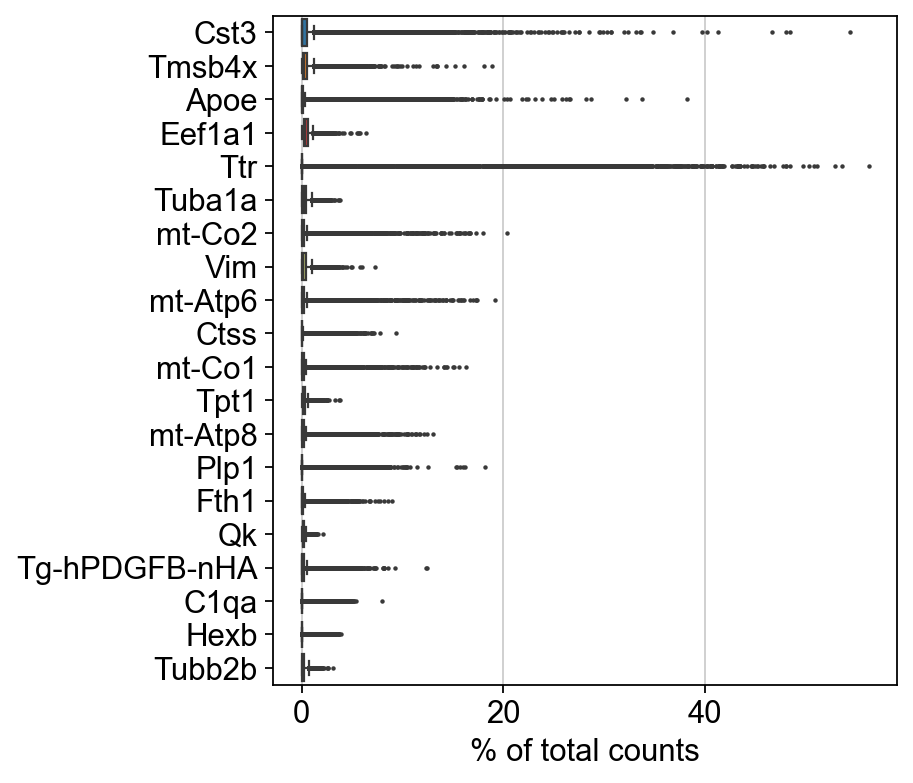

In [21]:
sc.pl.highest_expr_genes(adata, n_top=20, )

## Dropout rate
Yes, in single-cell RNA sequencing (scRNA-seq) data analysis, it's common to quantify the degree of zero-inflation or sparsity in the data. One common measure is the "dropout rate", which is the proportion of zero counts in the data matrix. 

Here's a simple way to calculate the dropout rate in Python, assuming `data` is a 2D numpy array or similar where rows are cells and columns are genes:

This will give you a value between 0 and 1, where 0 means no zero counts (no dropouts) and 1 means all counts are zero (all dropouts). 

Remember, high dropout rates are a common characteristic of scRNA-seq data due to technical limitations and biological variability.




In [22]:
import numpy as np

def calculate_dropout_rate(data):
    total_elements = np.prod(data.shape)
    zero_elements = np.sum(data == 0)
    dropout_rate = zero_elements / total_elements
    return dropout_rate

dropout_rate = calculate_dropout_rate(adata.X)
print(f"Dropout rate: {dropout_rate}")

/var/folders/1r/3rf4xlj152j5n2bfyjq1v58c0000gn/T/ipykernel_10298/2409461474.py:9: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  dropout_rate = calculate_dropout_rate(adata.X)


Dropout rate: 0.756205546152561


## Some basic QC metrics

In [23]:
# compute QC metrics. 
# First get the mitochondrial genes, starting with `MT-`
adata.var['mt'] = adata.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt' 
# print a table with how many genes are mitochondrial, i.e. `adata.var['mt']==True`
print(adata.var['mt'].value_counts())


mt
False    19060
True        13
Name: count, dtype: int64


In [24]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

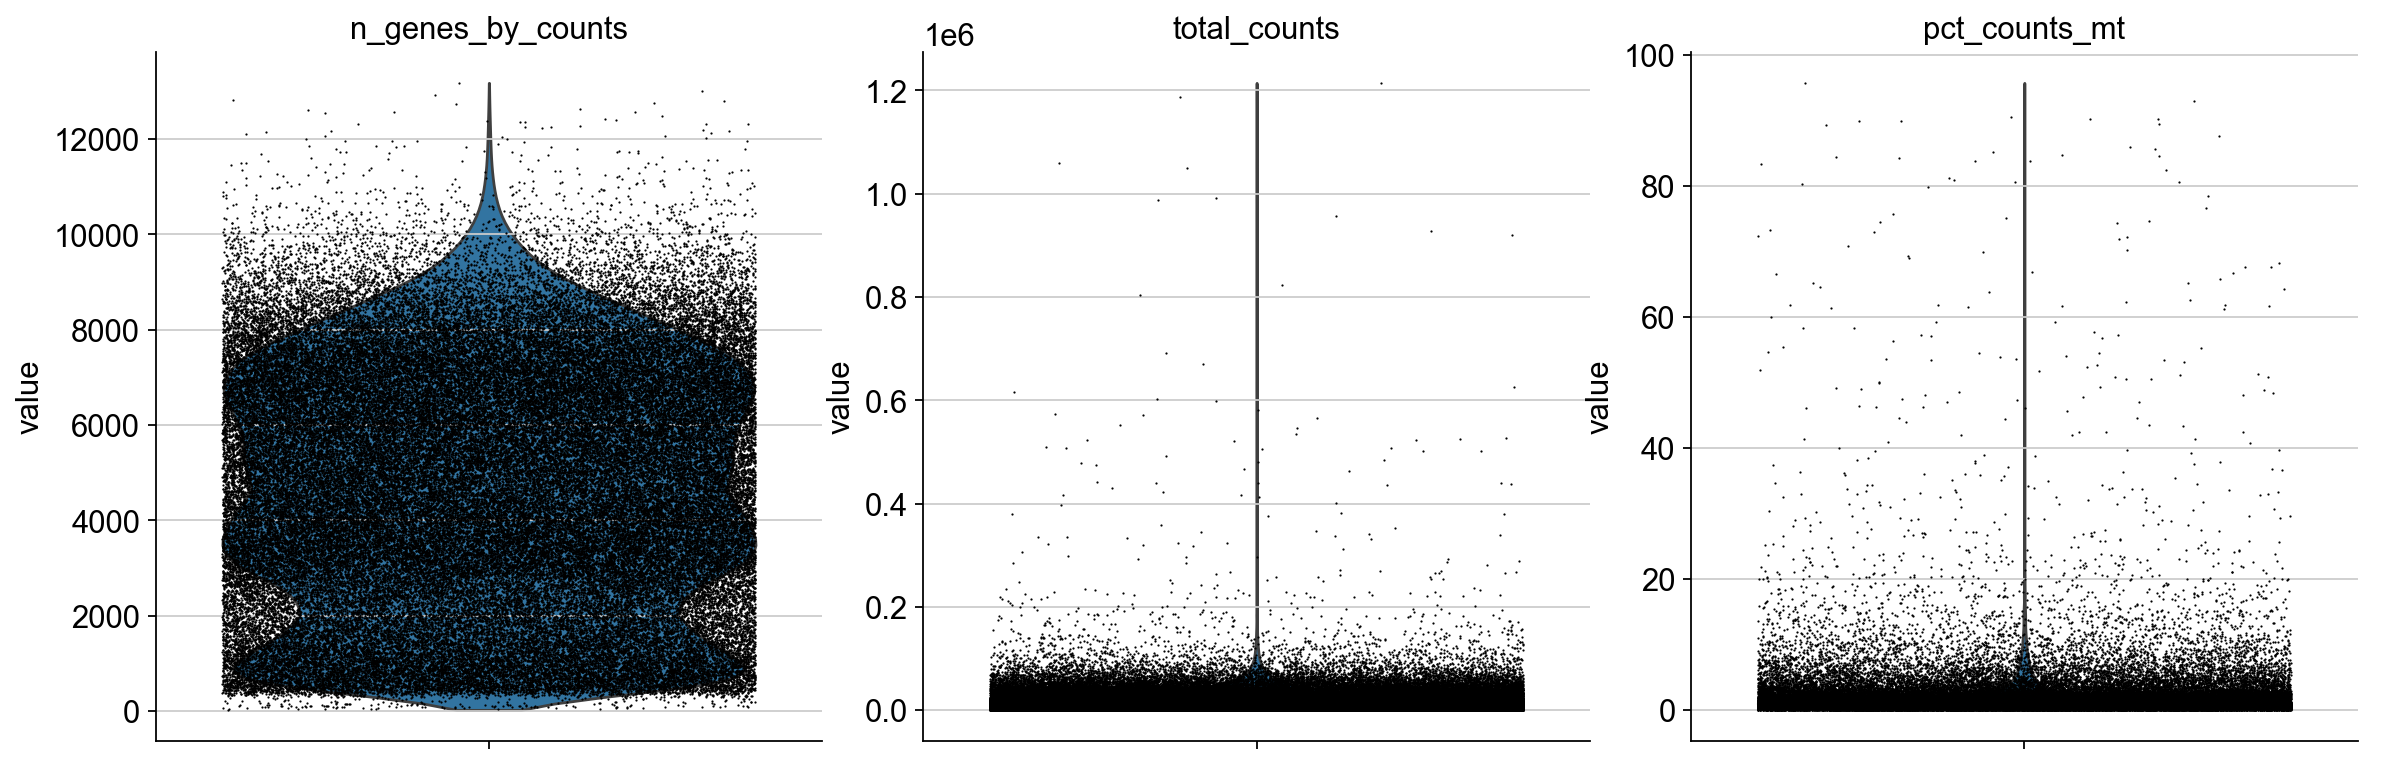

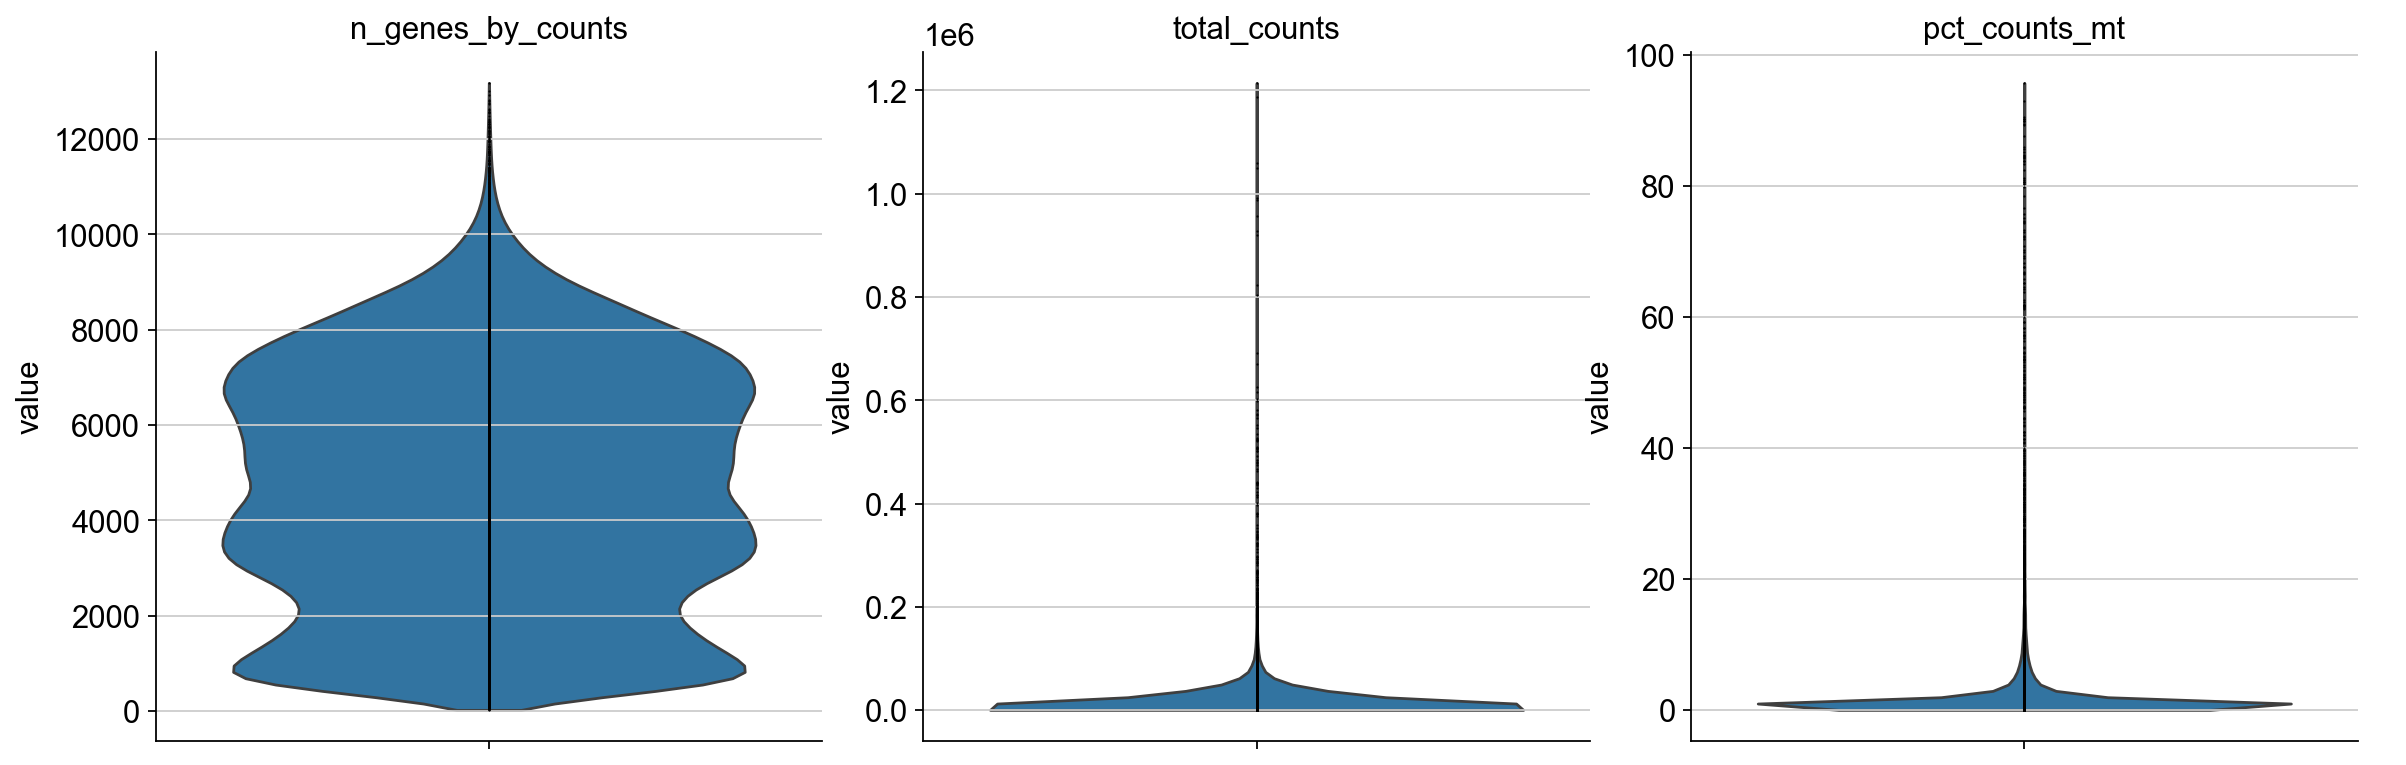

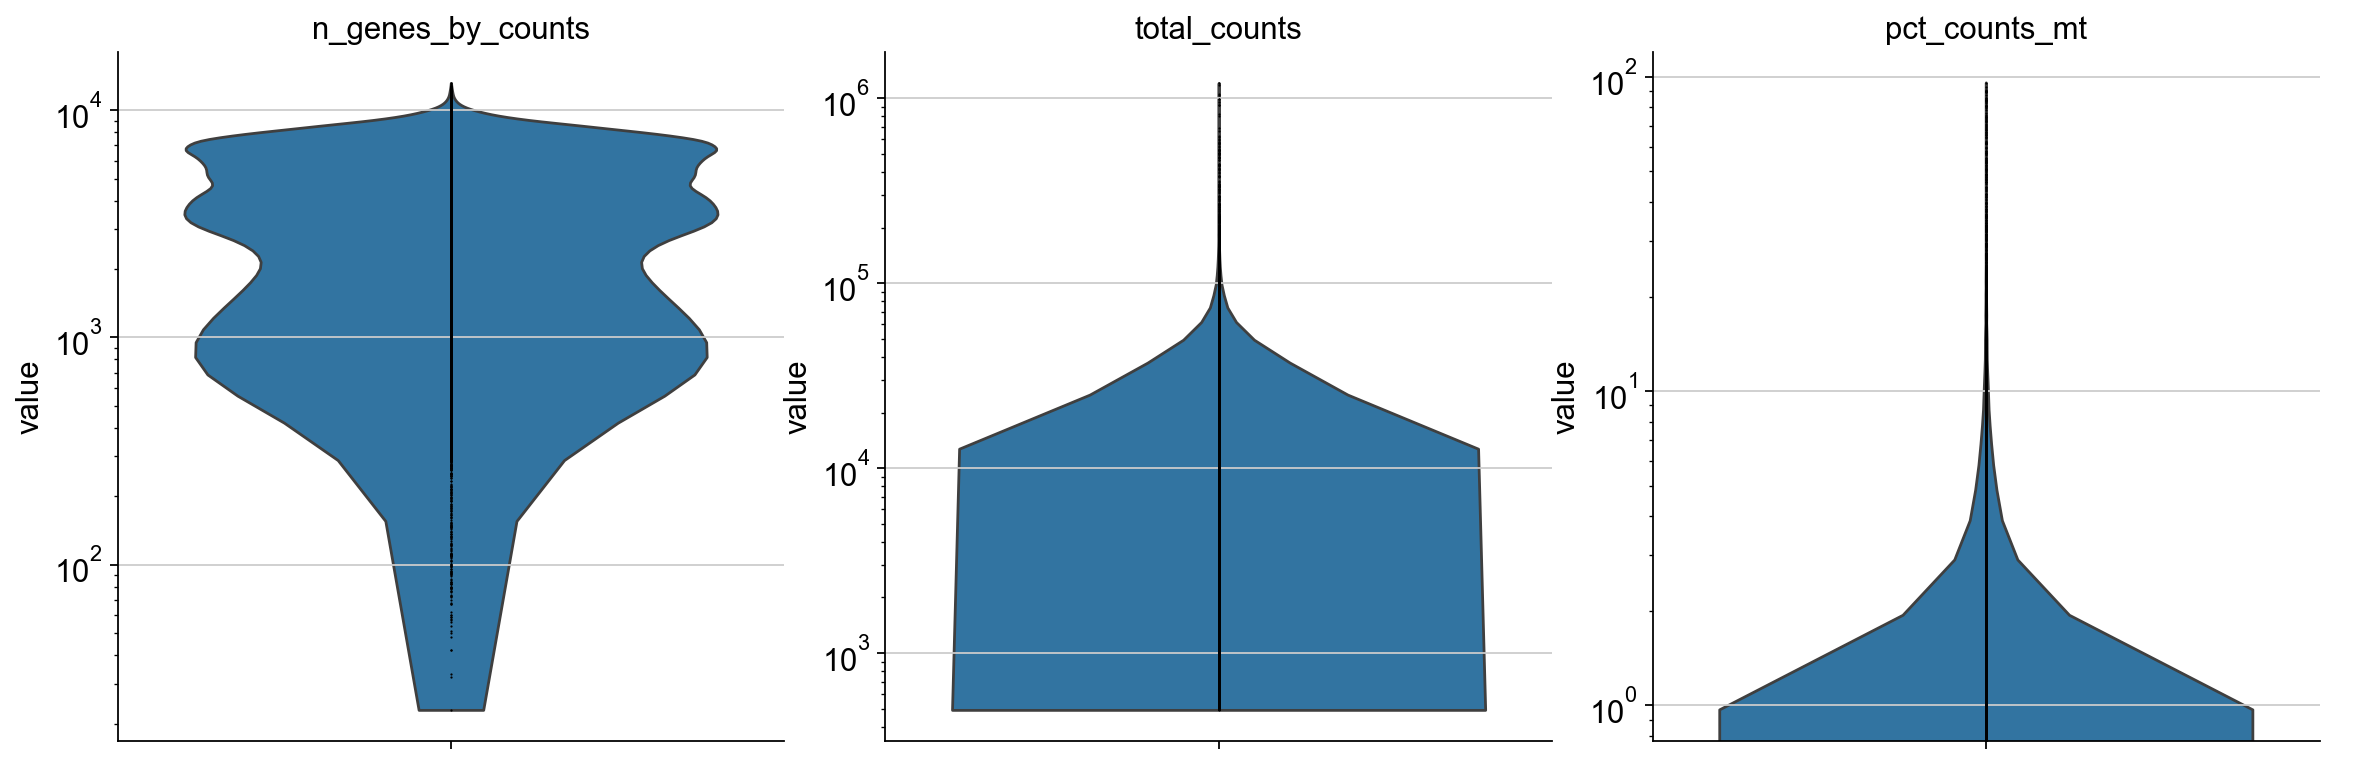

In [25]:
sc.pl.violin(
    adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4, multi_panel=True)

sc.pl.violin(
    adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0, multi_panel=True)

# same as above but log scale

sc.pl.violin(
    adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0, multi_panel=True, log=True)

In [26]:
import numpy as np

# Calculate the 5th and 95th percentiles for 'n_genes_by_counts'
n_genes_by_counts_5th = np.percentile(adata.obs['n_genes_by_counts'], 5)
n_genes_by_counts_95th = np.percentile(adata.obs['n_genes_by_counts'], 95)

# Calculate the 5th and 95th percentiles for 'total_counts'
total_counts_5th = np.percentile(adata.obs['total_counts'], 5)
total_counts_95th = np.percentile(adata.obs['total_counts'], 95)

print(f"5th percentile of 'n_genes_by_counts': {n_genes_by_counts_5th}")
print(f"95th percentile of 'n_genes_by_counts': {n_genes_by_counts_95th}")
print(f"5th percentile of 'total_counts': {total_counts_5th}")
print(f"95th percentile of 'total_counts': {total_counts_95th}")

# Do same but for 10 and 90 percentiles
n_genes_by_counts_10th = np.percentile(adata.obs['n_genes_by_counts'], 10)
n_genes_by_counts_90th = np.percentile(adata.obs['n_genes_by_counts'], 90)

total_counts_10th = np.percentile(adata.obs['total_counts'], 10)
total_counts_90th = np.percentile(adata.obs['total_counts'], 90)

print(f"10th percentile of 'n_genes_by_counts': {n_genes_by_counts_10th}")
print(f"90th percentile of 'n_genes_by_counts': {n_genes_by_counts_90th}")
print(f"10th percentile of 'total_counts': {total_counts_10th}")
print(f"90th percentile of 'total_counts': {total_counts_90th}")



5th percentile of 'n_genes_by_counts': 718.0
95th percentile of 'n_genes_by_counts': 8591.0
5th percentile of 'total_counts': 1091.0
95th percentile of 'total_counts': 57451.5625
10th percentile of 'n_genes_by_counts': 1103.0
90th percentile of 'n_genes_by_counts': 7951.400000000009
10th percentile of 'total_counts': 1792.0
90th percentile of 'total_counts': 43630.1953125


## Baic gene/cel filtering 
Use 95 and 5 % percentiles as cutoffs. Seem reasonable....

- 5th percentile of 'n_genes_by_counts': 718.0 - SET TO 500
- 95th percentile of 'n_genes_by_counts': 8591.0  - SET TO 9000
- 5th percentile of 'total_counts': 1091.0 - SET TO 1000
- 95th percentile of 'total_counts': 57451.59999999998 - SET TO 75000

10th percentile of 'n_genes_by_counts': 1103.0
90th percentile of 'n_genes_by_counts': 7951.400000000009
10th percentile of 'total_counts': 1792.0
90th percentile of 'total_counts': 43630.200000000026

In [27]:
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_genes(adata, min_cells=10)
adata

filtered out 1913 cells that have less than 500 genes expressed
filtered out 2153 genes that are detected in less than 10 cells


AnnData object with n_obs × n_vars = 90824 × 16920
    obs: 'cellranger_file', 'sample_id', 'mouse_id', 'sex', 'sample_type', 'disease_state', 'project_id', 'mouse_exp_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

Cutoff min_genes of 200 and min_cells 3, gave 4646 × 19073 down to 4633 × 15292

## Mitochondrial gene cell filter
mitochondrial genes, which are important for quality control.

13 mt genes. 
Calculate qc metrics

A violin plot of some of the computed quality measures:
the number of genes expressed in the count matrix
the total counts per cell
the percentage of counts in mitochondrial genes

Comments: 
Again an apparent bi-tri-modal distribution of cel n_genes. As previously show this cannot only be explained by e.g. multuplets or cell quality - there is an direct correlation between n-genes and cell type (biology). This is a hard nut, but care need to be taken when cutting 
Compared to the PBMC, we have quite a lot more n_genes_by_counts (median about 900 vs media 3000) and 7000. The binomial distribution pattern i do not understand ... Are what are the cells with n_genes around 1000 ?

Looking at distributions of nGenes and nUMI in the clustered data from Seurat - it seems so that the ~1000 gene cells are biologically valid (e.g. Astrocytes and Chroid cells). Microglia/macophages seem to express a whole lot more genes (~3000)

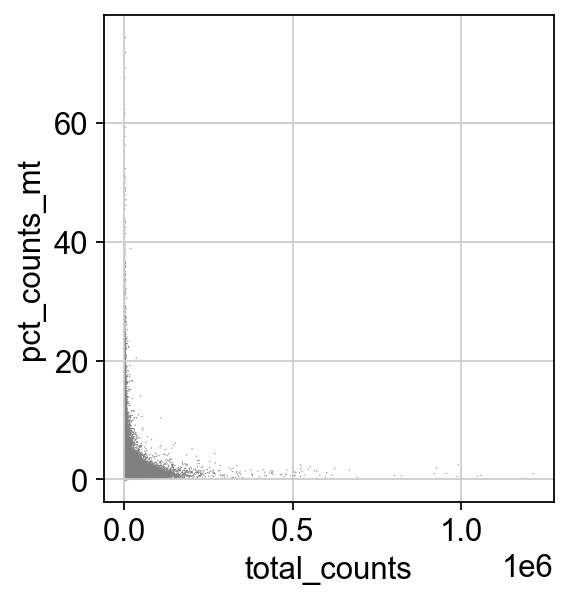

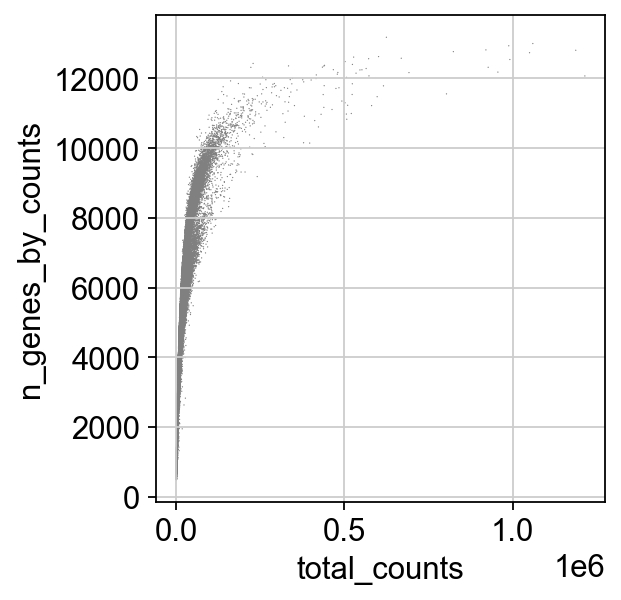

In [28]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

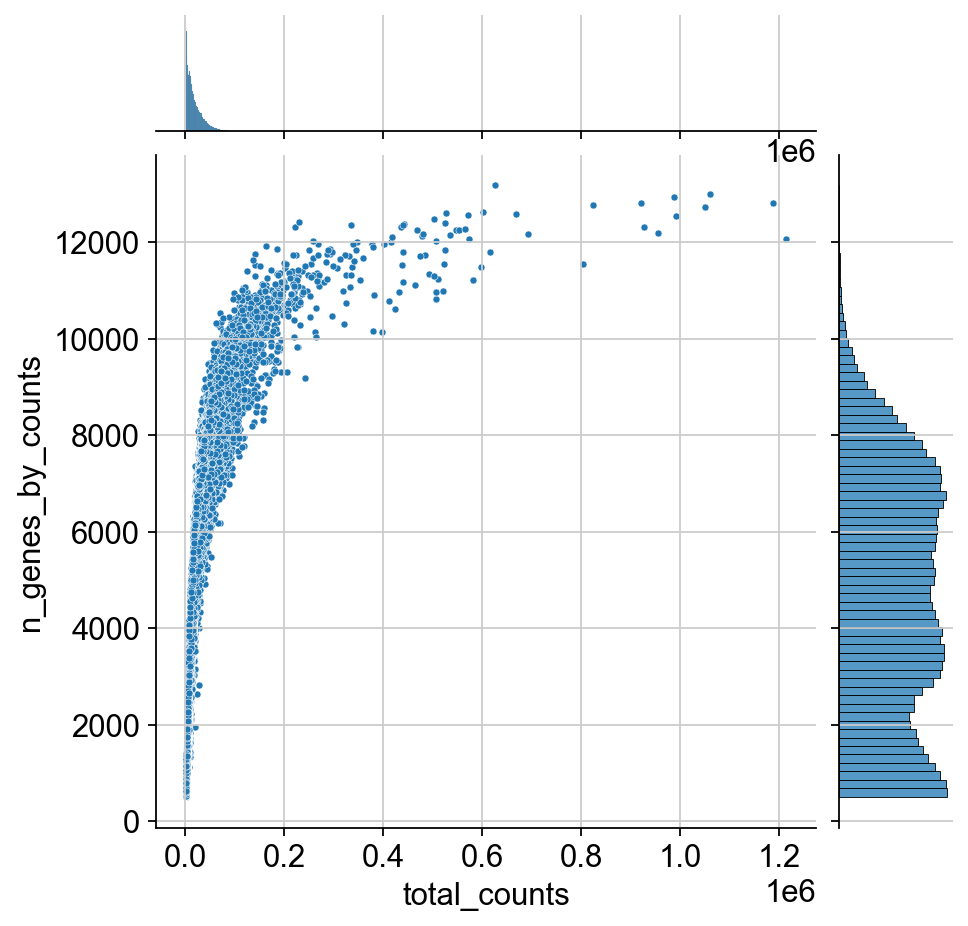

In [29]:
import seaborn as sns

# Extract the columns you're interested in from the AnnData object
df = adata.obs[['total_counts', 'n_genes_by_counts']]

# Create a jointplot
# sns.jointplot(data=df, x='total_counts', y='n_genes_by_counts', scatter_kws={"s": 10})
sns.jointplot(data=df, x='total_counts', y='n_genes_by_counts', joint_kws={"s": 10})

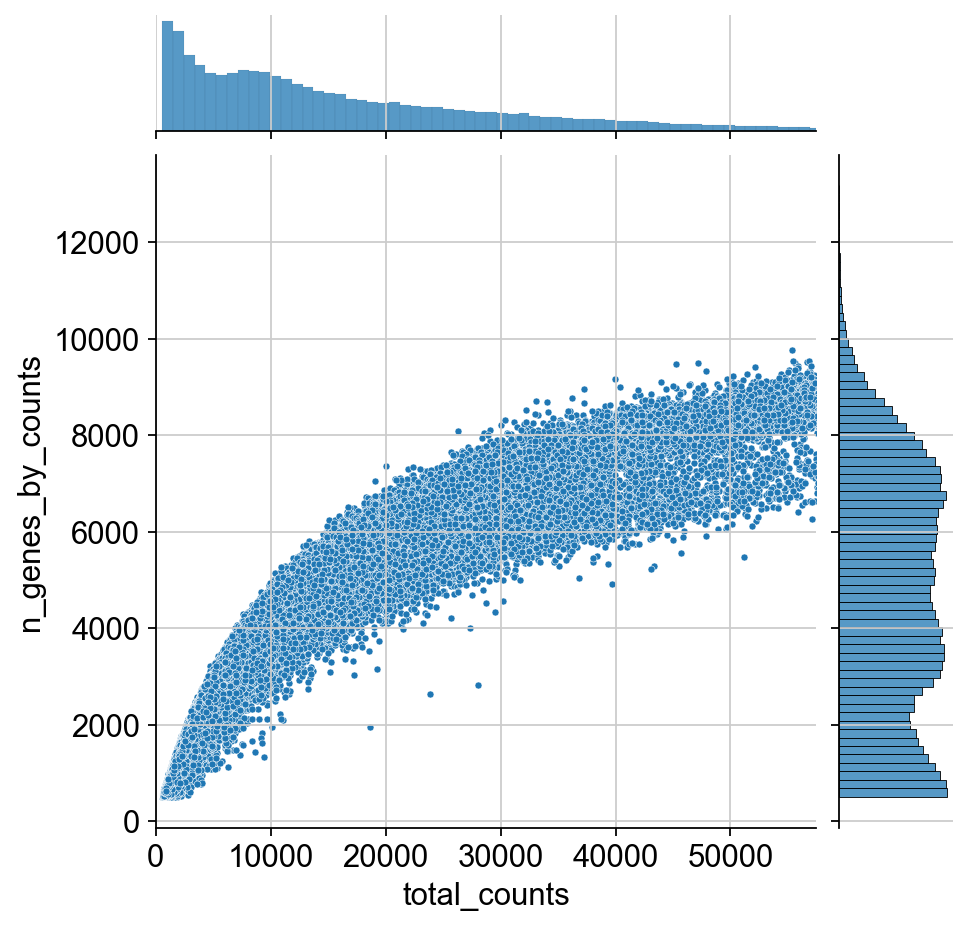

In [30]:
import matplotlib.pyplot as plt

joint_plot = sns.jointplot(data=df, x='total_counts', y='n_genes_by_counts', joint_kws={"s": 10})
plt.xlim(0, 57451)
plt.show()

## Set mt (max) cutoff and n_genes (max) cutoff

In [31]:
adata = adata[adata.obs.n_genes_by_counts < 10000, :]
adata = adata[adata.obs.pct_counts_mt < 10, :]
adata

View of AnnData object with n_obs × n_vars = 88794 × 16920
    obs: 'cellranger_file', 'sample_id', 'mouse_id', 'sex', 'sample_type', 'disease_state', 'project_id', 'mouse_exp_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'


 88793 × 16920
